Note: you may need to restart the kernel to use updated packages.
📡 Connecting to Global Markets... Fetching BTC-USD
✅ Data Acquired: 366 data points.


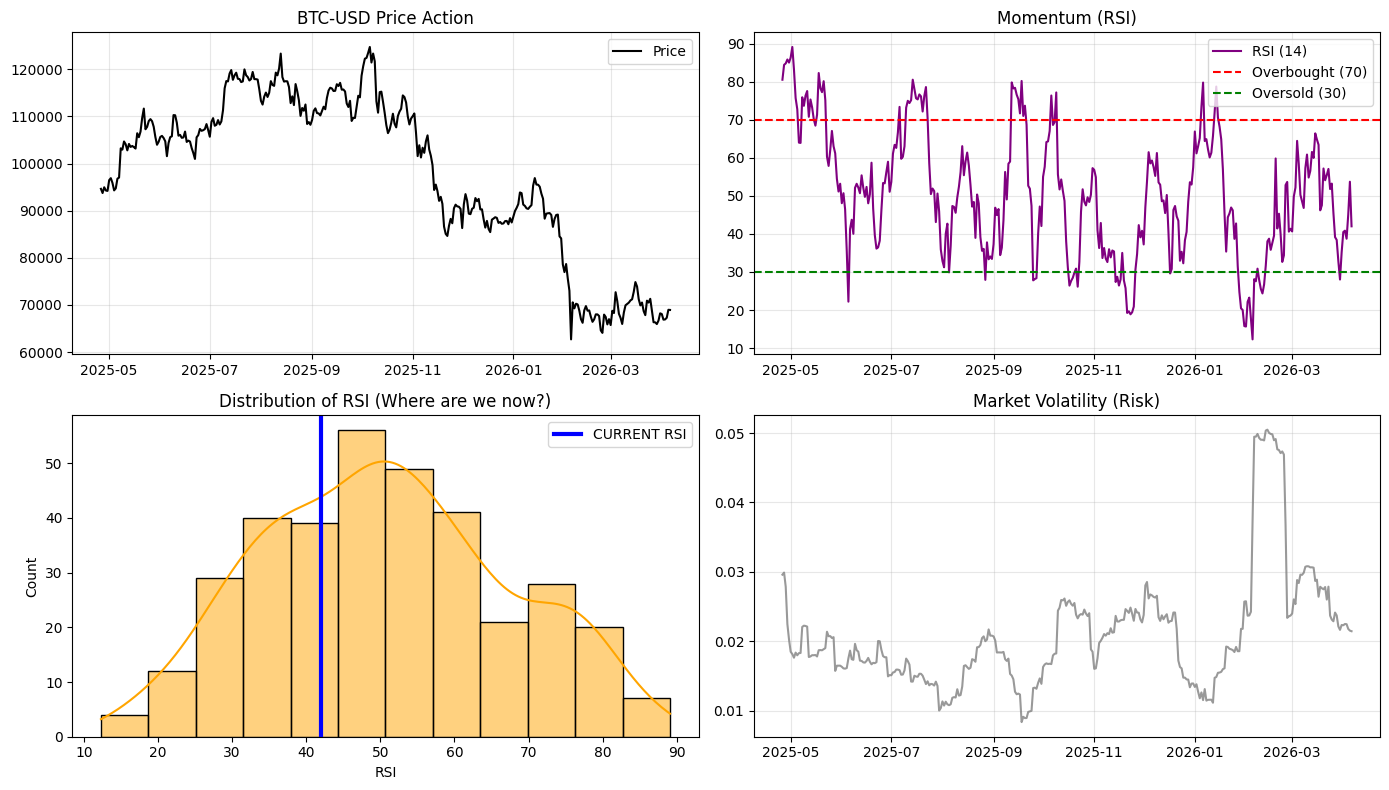


--- 🤖 ALGO SIGNAL REPORT: BTC-USD ---
Current Price: $68,946.89
Current RSI:   42.00
🔵 SIGNAL: MOMENTUM DOWN (Trend Following)


In [1]:
# --- STEP 0: INSTALL DEPENDENCIES (Run once) ---
%pip install yfinance pandas numpy matplotlib seaborn

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class IntelligencePipeline:
    def __init__(self, ticker):
        self.ticker = ticker
        self.data = None
        self.stats = {}

    # --- STEP 1: THE HARVESTER (Get Data) ---
    def fetch_data(self):
        print(f"📡 Connecting to Global Markets... Fetching {self.ticker}")
        
        # Download hourly data for the last 730 days (approx 1 month of hours)
        # We use '1h' interval to get more granular data for trading
        self.data = yf.download(self.ticker, period="1Y", interval="1d", progress=False)
        
        if self.data.empty:
            print("❌ Error: No data found. Check your internet or ticker symbol.")
            return
            
        print(f"✅ Data Acquired: {len(self.data)} data points.")

    # --- STEP 2: THE REFINER (Math & Indicators) ---
    def process_data(self):
        # Flatten MultiIndex columns if present (common yfinance issue)
        if isinstance(self.data.columns, pd.MultiIndex):
            self.data.columns = self.data.columns.get_level_values(0)
            
        # Calculate Returns
        self.data['Returns'] = self.data['Close'].pct_change()
        
        # Calculate RSI (Relative Strength Index) - The "Quant" way
        delta = self.data['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        self.data['RSI'] = 100 - (100 / (1 + rs))
        
        # Calculate Volatility (Standard Deviation of Returns)
        self.data['Volatility'] = self.data['Returns'].rolling(window=20).std()
        
        # Drop NaN values created by rolling windows
        self.data.dropna(inplace=True)

    # --- STEP 3: THE ANALYST (Statistical Truth) ---
    def analyze_stats(self):
        # We want to know: Is the current RSI "statistically" extreme?
        current_rsi = self.data['RSI'].iloc[-1]
        mean_rsi = self.data['RSI'].mean()
        std_rsi = self.data['RSI'].std()
        
        # Z-Score: How many standard deviations away from normal is the RSI?
        z_score = (current_rsi - mean_rsi) / std_rsi
        
        self.stats = {
            'price': self.data['Close'].iloc[-1],
            'rsi': current_rsi,
            'rsi_z_score': z_score,
            'volatility': self.data['Volatility'].iloc[-1]
        }

    # --- STEP 4: THE VISUALIZER (Graphs) ---
    def visualize(self):
        plt.figure(figsize=(14, 8))
        
        # Subplot 1: Price Action
        plt.subplot(2, 2, 1)
        plt.plot(self.data.index, self.data['Close'], label='Price', color='black')
        plt.title(f"{self.ticker} Price Action")
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        # Subplot 2: RSI Indicator
        plt.subplot(2, 2, 2)
        plt.plot(self.data.index, self.data['RSI'], label='RSI (14)', color='purple')
        plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
        plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')
        plt.title("Momentum (RSI)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Subplot 3: Statistical Distribution of RSI
        plt.subplot(2, 2, 3)
        sns.histplot(self.data['RSI'], kde=True, color='orange')
        plt.axvline(self.stats['rsi'], color='blue', linewidth=3, label='CURRENT RSI')
        plt.title(f"Distribution of RSI (Where are we now?)")
        plt.legend()
        
        # Subplot 4: Returns Volatility
        plt.subplot(2, 2, 4)
        plt.plot(self.data.index, self.data['Volatility'], color='gray', alpha=0.8)
        plt.title("Market Volatility (Risk)")
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    # --- THE EXECUTOR (The Signal) ---
    def get_signal(self):
        rsi = self.stats['rsi']
        price = self.stats['price']
        
        print(f"\n--- 🤖 ALGO SIGNAL REPORT: {self.ticker} ---")
        print(f"Current Price: ${price:,.2f}")
        print(f"Current RSI:   {rsi:.2f}")
        
        if rsi > 70:
            return "🔴 SIGNAL: SELL / SHORT (Market is Overheated)"
        elif rsi < 30:
            return "🟢 SIGNAL: BUY / LONG (Market is Oversold)"
        elif 45 < rsi < 55:
            return "⚪ SIGNAL: HOLD / WAIT (Market is Neutral)"
        else:
            direction = "Up" if rsi > 50 else "Down"
            return f"🔵 SIGNAL: MOMENTUM {direction.upper()} (Trend Following)"

# --- RUN THE BOT ---
if __name__ == "__main__":
    # Initialize the bot for Bitcoin
    bot = IntelligencePipeline("BTC-USD")
    
    # Run the 4 Steps
    bot.fetch_data()
    bot.process_data()
    bot.analyze_stats()
    bot.visualize()
    
    # Print the Final Verdict
    print(bot.get_signal())

📡 Connecting to Global Markets... Fetching BTC-USD
✅ Data Acquired: 366 data points.


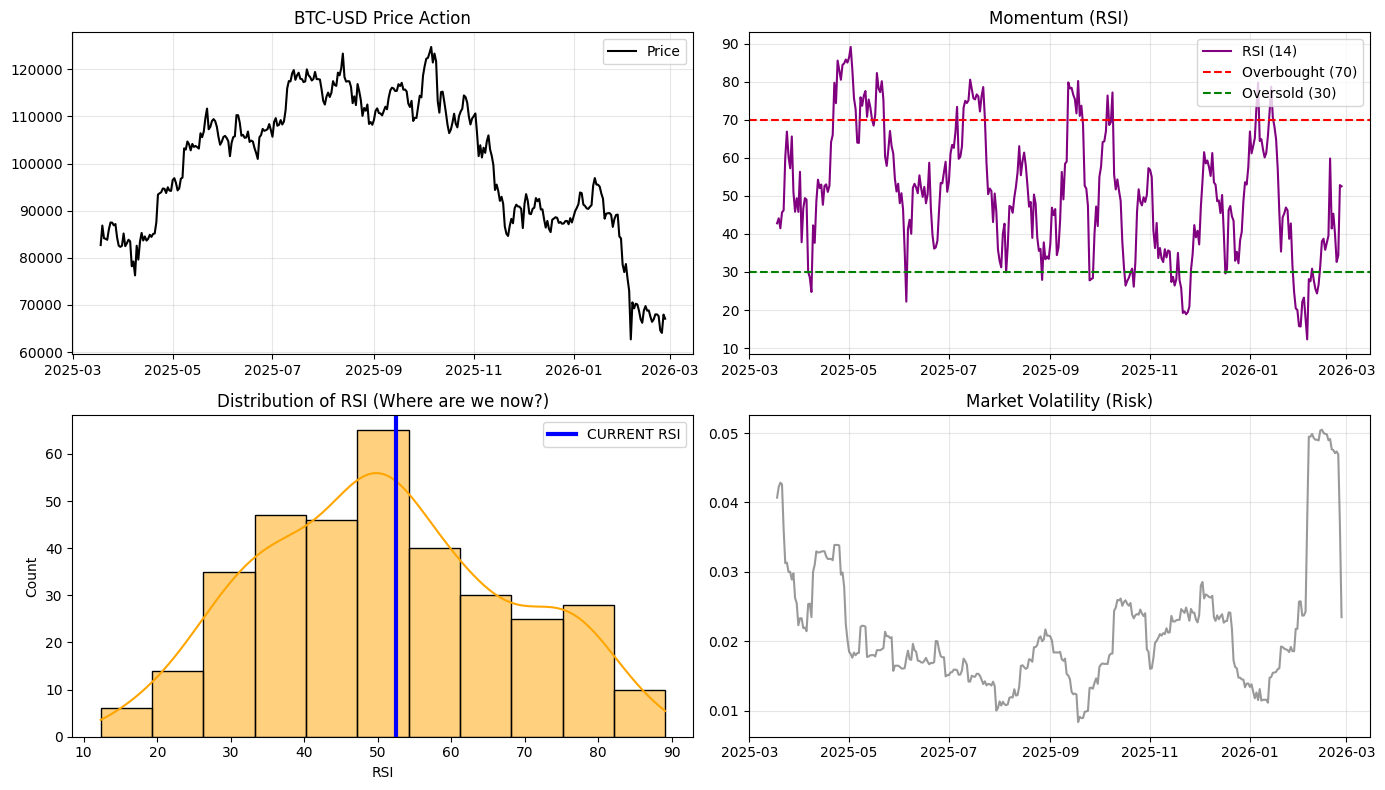


--- 🤖 ALGO SIGNAL REPORT: BTC-USD ---
Current Price: $67,085.12
Current RSI:   52.50
⚪ SIGNAL: HOLD / WAIT (Market is Neutral)


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class IntelligencePipeline:
    def __init__(self, ticker):
        self.ticker = ticker
        self.data = None
        self.stats = {}

    # --- STEP 1: THE HARVESTER (Get Data) ---
    def fetch_data(self):
        print(f"📡 Connecting to Global Markets... Fetching {self.ticker}")
        
        # Download hourly data for the last 730 days (approx 1 month of hours)
        # We use '1h' interval to get more granular data for trading
        self.data = yf.download(self.ticker, period="1Y", interval="1d", progress=False)
        
        if self.data.empty:
            print("❌ Error: No data found. Check your internet or ticker symbol.")
            return
            
        print(f"✅ Data Acquired: {len(self.data)} data points.")

    # --- STEP 2: THE REFINER (Math & Indicators) ---
    def process_data(self):
        # Flatten MultiIndex columns if present (common yfinance issue)
        if isinstance(self.data.columns, pd.MultiIndex):
            self.data.columns = self.data.columns.get_level_values(0)
            
        # Calculate Returns
        self.data['Returns'] = self.data['Close'].pct_change()
        
        # Calculate RSI (Relative Strength Index) - The "Quant" way
        delta = self.data['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        self.data['RSI'] = 100 - (100 / (1 + rs))
        
        # Calculate Volatility (Standard Deviation of Returns)
        self.data['Volatility'] = self.data['Returns'].rolling(window=20).std()
        
        # Drop NaN values created by rolling windows
        self.data.dropna(inplace=True)

    # --- STEP 3: THE ANALYST (Statistical Truth) ---
    def analyze_stats(self):
        # We want to know: Is the current RSI "statistically" extreme?
        current_rsi = self.data['RSI'].iloc[-1]
        mean_rsi = self.data['RSI'].mean()
        std_rsi = self.data['RSI'].std()
        
        # Z-Score: How many standard deviations away from normal is the RSI?
        z_score = (current_rsi - mean_rsi) / std_rsi
        
        self.stats = {
            'price': self.data['Close'].iloc[-1],
            'rsi': current_rsi,
            'rsi_z_score': z_score,
            'volatility': self.data['Volatility'].iloc[-1]
        }

    # --- STEP 4: THE VISUALIZER (Graphs) ---
    def visualize(self):
        plt.figure(figsize=(14, 8))
        
        # Subplot 1: Price Action
        plt.subplot(2, 2, 1)
        plt.plot(self.data.index, self.data['Close'], label='Price', color='black')
        plt.title(f"{self.ticker} Price Action")
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        # Subplot 2: RSI Indicator
        plt.subplot(2, 2, 2)
        plt.plot(self.data.index, self.data['RSI'], label='RSI (14)', color='purple')
        plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
        plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')
        plt.title("Momentum (RSI)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Subplot 3: Statistical Distribution of RSI
        plt.subplot(2, 2, 3)
        sns.histplot(self.data['RSI'], kde=True, color='orange')
        plt.axvline(self.stats['rsi'], color='blue', linewidth=3, label='CURRENT RSI')
        plt.title(f"Distribution of RSI (Where are we now?)")
        plt.legend()
        
        # Subplot 4: Returns Volatility
        plt.subplot(2, 2, 4)
        plt.plot(self.data.index, self.data['Volatility'], color='gray', alpha=0.8)
        plt.title("Market Volatility (Risk)")
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    # --- THE EXECUTOR (The Signal) ---
    def get_signal(self):
        rsi = self.stats['rsi']
        price = self.stats['price']
        
        print(f"\n--- 🤖 ALGO SIGNAL REPORT: {self.ticker} ---")
        print(f"Current Price: ${price:,.2f}")
        print(f"Current RSI:   {rsi:.2f}")
        
        if rsi > 70:
            return "🔴 SIGNAL: SELL / SHORT (Market is Overheated)"
        elif rsi < 30:
            return "🟢 SIGNAL: BUY / LONG (Market is Oversold)"
        elif 45 < rsi < 55:
            return "⚪ SIGNAL: HOLD / WAIT (Market is Neutral)"
        else:
            direction = "Up" if rsi > 50 else "Down"
            return f"🔵 SIGNAL: MOMENTUM {direction.upper()} (Trend Following)"

# --- RUN THE BOT ---
if __name__ == "__main__":
    # Initialize the bot for Bitcoin
    bot = IntelligencePipeline("BTC-USD")
    
    # Run the 4 Steps
    bot.fetch_data()
    bot.process_data()
    bot.analyze_stats()
    bot.visualize()
    
    # Print the Final Verdict
    print(bot.get_signal())